# pymfx — Visualization

This notebook demonstrates the three visualization functions in `pymfx.viz`:

1. **`trajectory_map`** — interactive Leaflet map of the GPS trace (folium)
2. **`flight_profile`** — altitude, speed and heading over time (matplotlib)
3. **`events_timeline`** — all flight events on a horizontal timeline (matplotlib)

**Requirements:**
```bash
pip install pymfx[viz]
# or
pip install folium matplotlib
```

In [1]:
import sys
sys.path.insert(0, '..')  # if running from notebooks/

import math, uuid
import matplotlib.pyplot as plt

import pymfx
from pymfx import viz
from pymfx.models import (
    MfxFile, Meta, Trajectory, TrajectoryPoint, SchemaField,
    Events, Event, Index
)
from pymfx import compute_checksum

print(f"pymfx {pymfx.__version__}")

pymfx 1.0.0


## Build a rich demo mission

We generate a 60-point coastal survey with altitude, speed, heading data and 5 events.

In [2]:
BASE_LAT, BASE_LON = 43.4832, -1.5586
FREQ = 10  # Hz

raw_pts = []
for i in range(60):
    t   = round(i / FREQ, 3)
    lat = round(BASE_LAT + i * 0.00005, 6)
    lon = round(BASE_LON + math.sin(i * 0.3) * 0.0003, 6)
    alt = round(50.0 + math.sin(i * 0.2) * 2.0, 1)
    spd = round(8.0  + math.cos(i * 0.15) * 1.5, 1)
    hdg = round((i * 6) % 360, 1)
    raw_pts.append((t, lat, lon, alt, spd, hdg))

schema_fields = [
    SchemaField('t',        'float',   ['no_null']),
    SchemaField('lat',      'float',   ['range=-90..90', 'no_null']),
    SchemaField('lon',      'float',   ['range=-180..180', 'no_null']),
    SchemaField('alt_m',    'float32', ['range=0..10000']),
    SchemaField('speed_ms', 'float32', ['range=0..200']),
    SchemaField('heading',  'float32', ['range=0..360']),
]

points  = [TrajectoryPoint(t=r[0], lat=r[1], lon=r[2], alt_m=r[3], speed_ms=r[4], heading=r[5]) for r in raw_pts]
raw_lines = [f"{r[0]:.3f} | {r[1]} | {r[2]} | {r[3]} | {r[4]} | {r[5]}" for r in raw_pts]

event_schema = [
    SchemaField('t',        'float', ['no_null']),
    SchemaField('type',     'str',   ['enum=[takeoff,landing,waypoint,anomaly,rtl,abort]']),
    SchemaField('severity', 'str',   ['enum=[info,warning,critical]']),
    SchemaField('detail',   'str'),
]

event_list = [
    Event(t=0.0, type='takeoff',  severity='info',    detail='nominal'),
    Event(t=2.0, type='waypoint', severity='info',    detail='wp1'),
    Event(t=3.5, type='anomaly',  severity='warning', detail='wind_gust'),
    Event(t=4.8, type='waypoint', severity='info',    detail='wp2'),
    Event(t=5.9, type='landing',  severity='info',    detail='nominal'),
]
ev_raw = [f"{e.t:.3f} | {e.type} | {e.severity} | {e.detail}" for e in event_list]

lats = [p.lat for p in points]
lons = [p.lon for p in points]
bbox = (round(min(lons),6), round(min(lats),6), round(max(lons),6), round(max(lats),6))

mfx = MfxFile(
    version='1.0', encoding='UTF-8',
    meta=Meta(
        id=f'uuid:{uuid.uuid4()}',
        drone_id='DJI-Mavic3-SN112233',
        drone_type='multirotor',
        pilot_id='FR-PILOT-0042',
        date_start='2026-04-01T09:00:00Z',
        date_end='2026-04-01T09:08:20Z',
        duration_s=500,
        status='complete',
        application='coastal_survey',
        location='Biarritz, France',
        sensors=['rgb', 'thermal'],
        data_level='raw',
        license='CC-BY-4.0',
        contact='survey@coastal.fr',
    ),
    trajectory=Trajectory(
        frequency_hz=FREQ,
        schema_fields=schema_fields,
        points=points,
        checksum=compute_checksum(raw_lines),
        raw_lines=raw_lines,
    ),
    events=Events(
        schema_fields=event_schema,
        events=event_list,
        checksum=compute_checksum(ev_raw),
        raw_lines=ev_raw,
    ),
    index=Index(bbox=bbox, anomalies=1),
)

result = pymfx.validate(mfx)
print(result)

✓ Valid file — no issues found.


## 1. Trajectory map (folium)

The map renders inline in Jupyter. Click the event markers for details.

In [3]:
m = viz.trajectory_map(mfx)
m  # renders inline in Jupyter

In [ ]:
# Save as standalone HTML
m.save("flight_map.html")
print("Saved to flight_map.html")

In [4]:
# Options
m2 = viz.trajectory_map(
    mfx,
    tile="CartoDB positron",   # cleaner basemap
    show_points=False,          # hide individual point circles
    show_events=True,
    line_weight=5,
)
m2

## 2. Flight profile (matplotlib)

Each channel with available data gets its own subplot.
Event lines are overlaid automatically.

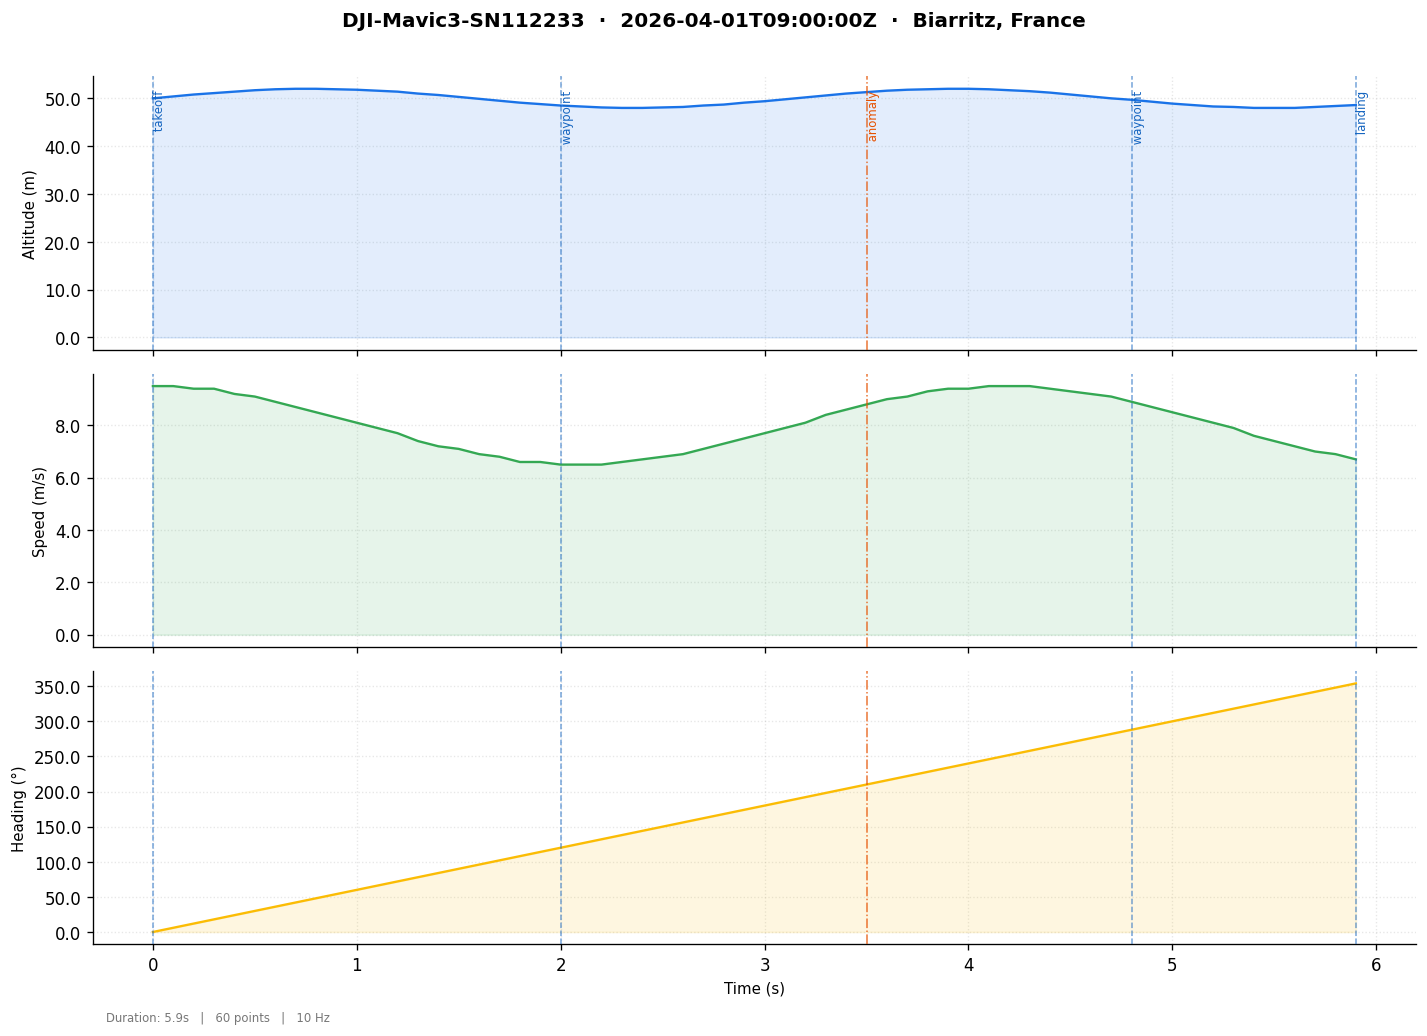

In [5]:
fig = viz.flight_profile(mfx)
plt.show()

In [6]:
# Save to file
fig.savefig("flight_profile.png", dpi=150, bbox_inches='tight')
print("Saved to flight_profile.png")

Saved to flight_profile.png


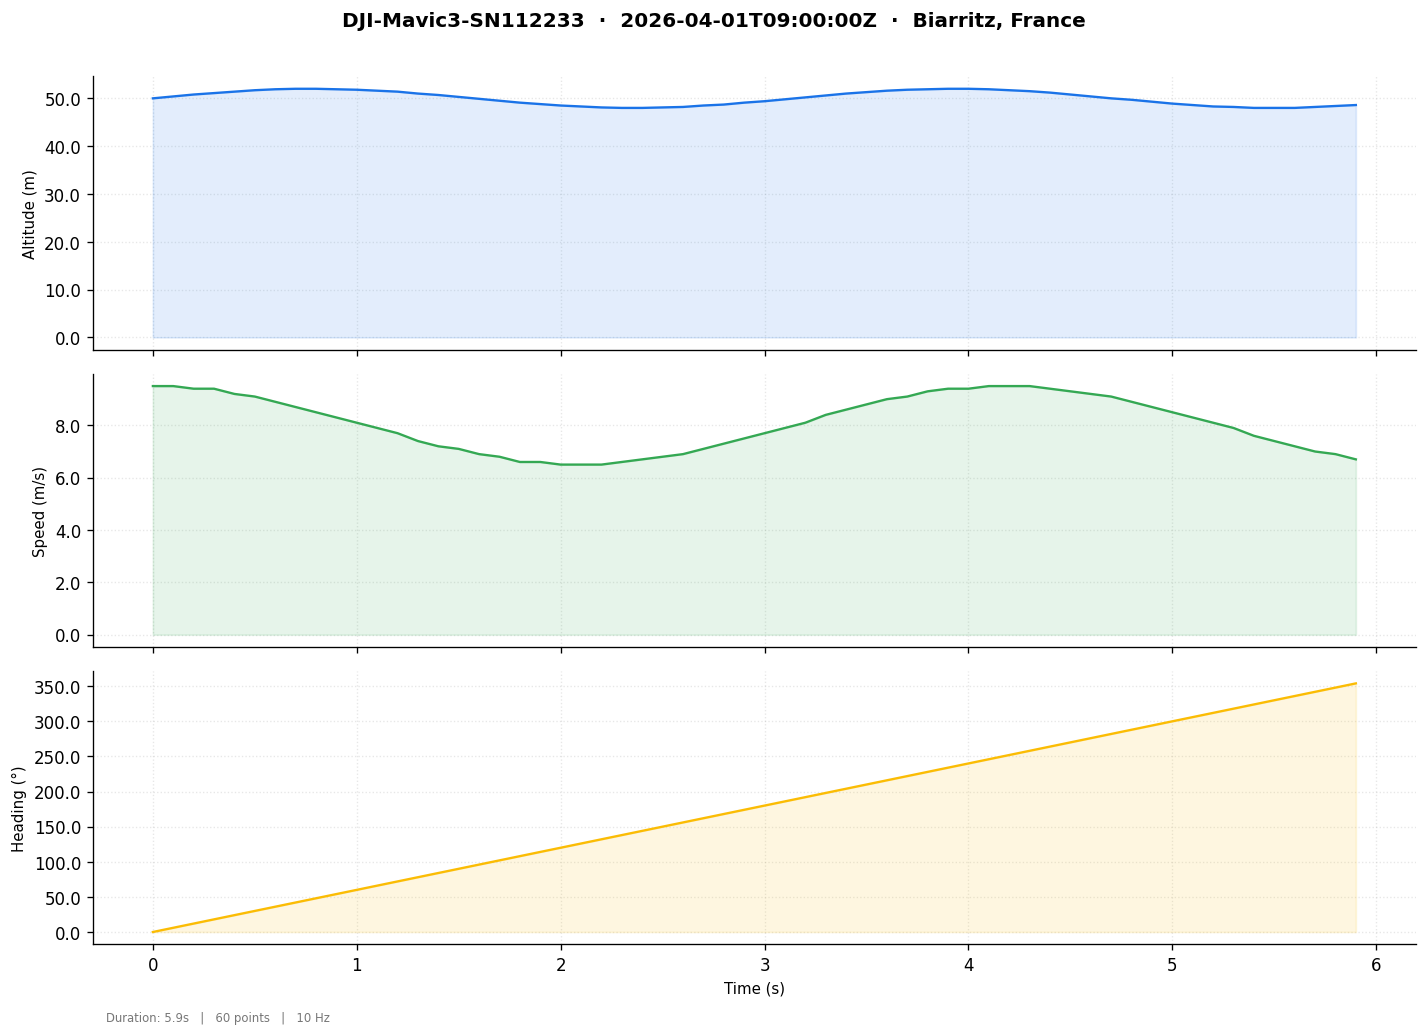

In [7]:
# Without event overlays
fig_no_events = viz.flight_profile(mfx, show_events=False)
plt.show()

## 3. Events timeline (matplotlib)

All events are shown on a horizontal timeline with severity color-coding.

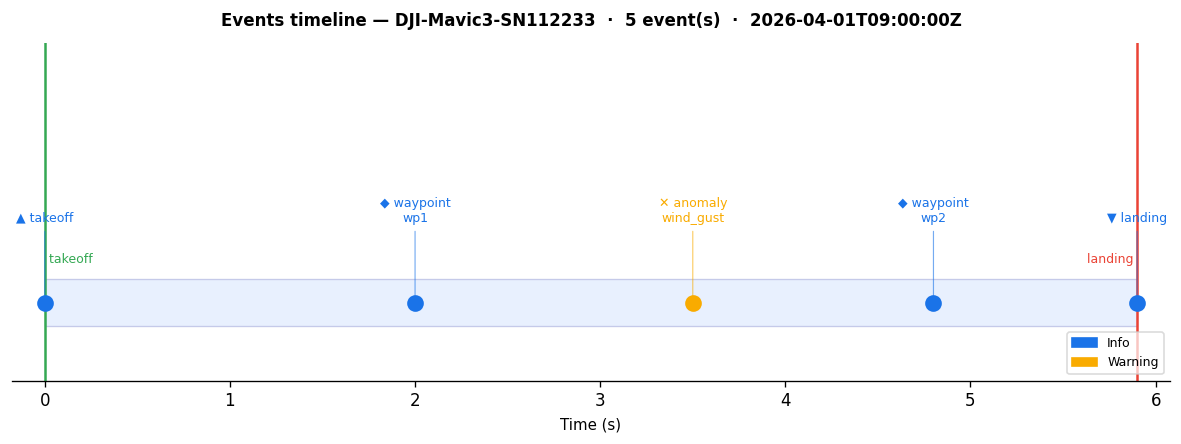

In [8]:
fig_tl = viz.events_timeline(mfx)
plt.show()

In [9]:
fig_tl.savefig("events_timeline.png", dpi=150, bbox_inches='tight')
print("Saved to events_timeline.png")

Saved to events_timeline.png


## 4. Load from an existing .mfx file

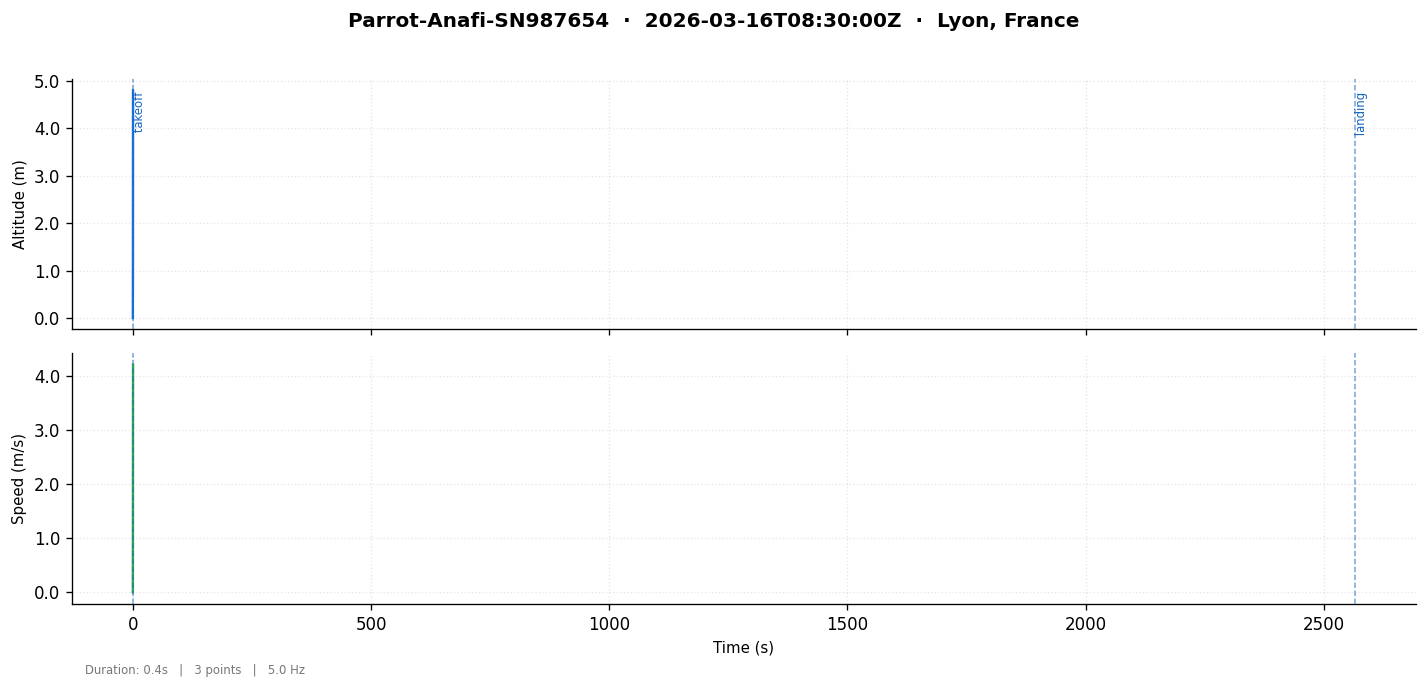

/Users/cmg203/Downloads/pymfx/notebooks/../pymfx/viz/timeline.py:163: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


In [10]:
# Works with any valid .mfx file
mfx_loaded = pymfx.parse("../tests/example_minimal.mfx")

# The example has no heading/roll/pitch, only alt and speed
fig_minimal = viz.flight_profile(mfx_loaded)
plt.show()

# Timeline
fig_tl_minimal = viz.events_timeline(mfx_loaded)
plt.show()